In [3]:
import pandas as pd
import numpy as np
import os
import re
import datetime as datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from unidecode import unidecode
from tqdm import tqdm
from transformers import (
    MarianMTModel,
    MarianTokenizer,
    AutoTokenizer,
    AutoModelForSequenceClassification
)
import torch
from dotenv import load_dotenv
import google.generativeai as genai
from langchain_community.vectorstores import FAISS
from langchain_community.docstore.document import Document

C:\Users\hp\AppData\Local\Temp\ipykernel_12564\4133459671.py:26: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [4]:
df = pd.read_csv(r"D:\ai-seller-risk-intelligence-system\data\processed\late_delivery_dataset.csv")

In [5]:
df.head()

,order_id,seller_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,late_delivery,delivery_days,estimated_delivery_days,order_month,order_weekday,total_payment_value,avg_installments,total_price,total_freight,total_items
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,9/13/2017 8:59,9/20/2017 23:43,9/29/2017 0:00,0,7,16,9,4,72.19,2.0,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,4/26/2017 10:53,5/12/2017 16:04,5/15/2017 0:00,0,16,19,4,4,259.83,3.0,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,1/14/2018 14:33,1/22/2018 13:19,2/5/2018 0:00,0,8,22,1,1,216.87,5.0,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,8/8/2018 10:00,8/14/2018 13:32,8/20/2018 0:00,0,6,12,8,4,25.78,2.0,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,2/4/2017 13:57,3/1/2017 16:42,3/17/2017 0:00,0,25,41,2,7,218.04,3.0,199.90,18.14,1


In [6]:
df.shape

(96477, 15)

In [7]:
df.dtypes

order_id                          object
seller_id                         object
order_purchase_timestamp          object
order_delivered_customer_date     object
order_estimated_delivery_date     object
late_delivery                      int64
delivery_days                     object
estimated_delivery_days            int64
order_month                        int64
order_weekday                      int64
total_payment_value              float64
avg_installments                 float64
total_price                      float64
total_freight                    float64
total_items                        int64
dtype: object

In [8]:
df.columns

Index(['order_id', 'seller_id', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'late_delivery', 'delivery_days', 'estimated_delivery_days',
       'order_month', 'order_weekday', 'total_payment_value',
       'avg_installments', 'total_price', 'total_freight', 'total_items'],
      dtype='object')

In [9]:
df.late_delivery.value_counts(normalize = True)

late_delivery
0    0.918893
1    0.081107
Name: proportion, dtype: float64

In [10]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

In [11]:
df = df.drop(columns= ['order_id','delivery_days', 'order_purchase_timestamp', 'order_delivered_customer_date','order_estimated_delivery_date'])

In [12]:
df.head()

,seller_id,late_delivery,estimated_delivery_days,order_month,order_weekday,total_payment_value,avg_installments,total_price,total_freight,total_items
0,48436dade18ac8b2bce089ec2a041202,0,16,9,4,72.19,2.0,58.90,13.29,1
1,dd7ddc04e1b6c2c614352b383efe2d36,0,19,4,4,259.83,3.0,239.90,19.93,1
2,5b51032eddd242adc84c38acab88f23d,0,22,1,1,216.87,5.0,199.00,17.87,1
3,9d7a1d34a5052409006425275ba1c2b4,0,12,8,4,25.78,2.0,12.99,12.79,1
4,df560393f3a51e74553ab94004ba5c87,0,41,2,7,218.04,3.0,199.90,18.14,1


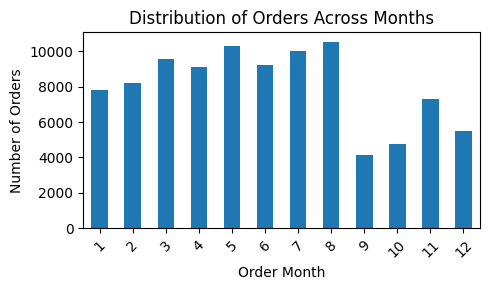

In [13]:
# Count orders by month
orders_month = df.groupby("order_month").size()

plt.figure(figsize=(5,3))
orders_month.plot(kind="bar")

plt.title("Distribution of Orders Across Months")
plt.xlabel("Order Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

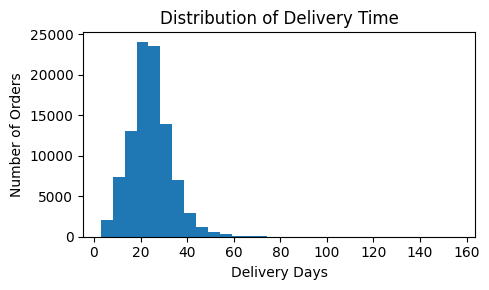

In [14]:
plt.figure(figsize=(5,3))

plt.hist(df["estimated_delivery_days"], bins=30)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [15]:
x = df.drop(['late_delivery'], axis = 1)
y = df['late_delivery']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state= 42, stratify=y)

In [17]:
train_df = x_train.copy()
train_df['late_orders'] = y_train

seller_delay = (
    train_df.groupby('seller_id')['late_orders'].mean().reset_index().rename(columns = {'late_orders' : 'seller_late_rate'})
)

In [18]:
# x_train = x_train.merge(seller_delay, on= 'seller_id', how = 'left')
# x_test = x_test.merge(seller_delay, on = 'seller_id', how = 'left')

seller_rate_dict = dict(
    zip(seller_delay['seller_id'], seller_delay['seller_late_rate'])
)
x_train['seller_late_rate'] = x_train['seller_id'].map(seller_rate_dict)
x_test['seller_late_rate'] = x_test['seller_id'].map(seller_rate_dict)

In [19]:
mean_rate = seller_delay['seller_late_rate'].mean()
x_train['seller_late_rate'] = x_train['seller_late_rate'].fillna(mean_rate)
x_test['seller_late_rate'] = x_test['seller_late_rate'].fillna(mean_rate)

In [20]:
x_train = x_train.drop(columns = ['seller_id'])
x_test = x_test.drop(columns =['seller_id'])

In [21]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
lr = LogisticRegression(max_iter= 1000, class_weight='balanced')
lr.fit(x_train_scaled, y_train)

y_pred = lr.predict(x_test_scaled)
y_prob = lr.predict_proba(x_test_scaled)[:,1]

In [23]:
print(classification_report(y_test,y_pred))
print("ROC AUC: ",roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.94      0.70      0.80     17731
           1       0.12      0.46      0.19      1565

    accuracy                           0.68     19296
   macro avg       0.53      0.58      0.49     19296
weighted avg       0.87      0.68      0.75     19296

ROC AUC:  0.620519575199336


In [24]:
rf = RandomForestClassifier(n_estimators= 200, max_depth= None, class_weight= 'balanced', random_state= 42)

In [ ]:
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
y_prob_rf = rf.predict_proba(x_test)[:,1]

print(classification_report(y_test,y_pred_rf))
print("ROC AUC: ",roc_auc_score(y_test, y_prob_rf))

In [ ]:
threshold = 0.20
y_pred_adj = (y_prob_rf >= threshold).astype(int)
print(classification_report(y_test, y_pred_adj))
print("ROC AUC: ",roc_auc_score(y_test, y_pred_adj))

In [ ]:
threshold = 0.15
y_pred_adj = (y_prob_rf >= threshold).astype(int)
print(classification_report(y_test, y_pred_adj))
print("ROC AUC: ",roc_auc_score(y_test, y_pred_adj))

In [ ]:
xgb = XGBClassifier(n_estimators= 300, 
                    max_depth = 6, 
                    learning_rate = 0.05, 
                    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
                    random_state = 42
                   )
xgb.fit(x_train, y_train)
y_prob_xgb = xgb.predict_proba(x_test)[:,1]
print("ROC AUC: ",roc_auc_score(y_test, y_prob_xgb))

In [ ]:
for threshold in [0.25, 0.20, 0.15]:
    y_pred_adj = (y_prob_xgb >= threshold).astype(int)
    print(f"\nThreshold : {threshold}")
    print(classification_report(y_test, y_pred_adj))
    print("ROC AUC: ",roc_auc_score(y_test, y_pred_adj))

In [ ]:
# optimal threshold
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)
f1_scores = 2 *(precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold: ", best_threshold)
print("Best F1: ",f1_scores[best_idx])

In [ ]:
import pandas as pd

feat_imp = pd.Series(
    xgb.feature_importances_,
    index=x_train.columns
).sort_values(ascending=False)

print(feat_imp.head(10))


In [ ]:
y_pred_best = (y_prob_xgb > best_threshold).astype(int)
print(classification_report(y_test, y_pred_best))

In [ ]:
train_df[train_df['late_orders'] == 1]

In [ ]:
seller_delay

In [ ]:
# Seller Health Index
seller_df = pd.read_csv(r"D:\ai-seller-risk-intelligence-system\data\processed\seller_metrics.csv")
seller_df.replace('\\N', np.nan, inplace=True)


In [ ]:
seller_df.head()

In [ ]:
seller_df.isna().sum()[seller_df.isna().sum() > 0]

In [ ]:
numeric_cols = ['total_orders', 'total_revenue', 'avg_order_value',
       'late_delivery_rate', 'avg_review_score', 'total_product_value',
       'total_freight_value']

for col in numeric_cols:
    seller_df[col] = pd.to_numeric(seller_df[col], errors = 'coerce')

In [ ]:
seller_df.columns

In [ ]:
seller_df['avg_review_score'] = seller_df['avg_review_score'].fillna(4.15)

In [ ]:
plt.figure(figsize=(5,3))

plt.scatter(
    seller_df["total_revenue"],
    seller_df["late_delivery_rate"]
)

plt.title("Seller Revenue vs Late Delivery Rate")
plt.xlabel("Total Revenue")
plt.ylabel("Late Delivery Rate")

plt.tight_layout()
plt.show()

In [ ]:
# Top sellers by revenue
top_sellers = seller_df.sort_values("total_revenue", ascending=False).head(10)

plt.figure(figsize=(5,3))

plt.bar(top_sellers["seller_id"], top_sellers["total_revenue"])

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Normalize Metrics
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

seller_df[['norm_revenue']] = scaler.fit_transform(seller_df[['total_revenue']])
seller_df[['norm_orders']] = scaler.fit_transform(seller_df[['total_orders']])
seller_df[['norm_review']] = scaler.fit_transform(seller_df[['avg_review_score']])
seller_df['inv_late_rate'] = 1 - seller_df['late_delivery_rate']
seller_df[['norm_late']] = scaler.fit_transform(seller_df[['inv_late_rate']])

In [ ]:
seller_df.head()

In [ ]:
# 40% delivery reliability
# 30% review score
# 20% revenue
# 10% volume
seller_df['seller_health_index'] = (
    0.4 * seller_df['norm_late'] + 
    0.3 * seller_df['norm_review'] + 
    0.2 * seller_df['norm_revenue'] + 
    0.1 * seller_df['norm_orders']
)

In [ ]:
seller_df

In [ ]:
# Rank Sellers
seller_df = seller_df.sort_values(by = 'seller_health_index', ascending= False)
seller_df[['seller_id','seller_health_index']].head(10)

In [ ]:
seller_df[['seller_id','seller_health_index']].tail(10)

In [ ]:
seller_df[['seller_health_index' , 'late_delivery_rate']].corr()

In [ ]:
# Seller Segmentation
features = seller_df[['late_delivery_rate',	'avg_review_score', 'total_revenue', 'total_orders']]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters= 4, random_state= 42)
seller_df['seller_segment'] = kmeans.fit_predict(scaled_features)

In [ ]:
seller_df.groupby('seller_segment')[['late_delivery_rate',	'avg_review_score', 'total_revenue', 'total_orders']].mean()

In [ ]:
seller_df.groupby('seller_segment')['total_revenue'].sum()

In [ ]:
# Revenue Share by Segment
seller_df.groupby('seller_segment')['total_revenue'].sum().sort_values(ascending= False)

In [ ]:
segment_revenue = seller_df.groupby('seller_segment')['total_revenue'].sum()
segment_revenue_pct = round(segment_revenue / segment_revenue.sum(), 2) * 100
segment_revenue_pct

In [ ]:
seller_df['revenue_at_risk'] = (seller_df['total_revenue'] * seller_df['late_delivery_rate'])

In [ ]:
seller_df.groupby('seller_segment')[['revenue_at_risk', 'total_revenue']].sum()

In [ ]:
seller_df['reputation_risk'] = (seller_df['late_delivery_rate'] * (5 -seller_df['avg_review_score']))

In [ ]:
seller_df.head(5)

In [ ]:
seller_df.groupby('seller_segment')['reputation_risk'].mean()

In [ ]:
# summary
segment_summary = seller_df.groupby('seller_segment').agg({
    'total_revenue' : 'sum',
    'late_delivery_rate' : 'mean',
    'avg_review_score' : 'mean',
    'revenue_at_risk' : 'sum'
})
segment_summary

In [ ]:
sns.boxplot(
    x = 'seller_segment',
    y = 'late_delivery_rate',
    data = seller_df
)
plt.title('Late Delivery Rate by Seller Segment')
plt.show()

In [ ]:
sns.scatterplot(
    x = 'total_revenue',
    y = 'late_delivery_rate',
    hue = 'seller_segment',
    data = seller_df
)
plt.xscale('log')
plt.title('Revenue vs Late Rate')
plt.show()

In [ ]:
# clean text
df = pd.read_csv(r"D:\ai-seller-risk-intelligence-system\data\processed\dl_dataset.csv")

In [ ]:
df.head()

In [ ]:
df['review_score'] = pd.to_numeric(df['review_score'] , errors = 'coerce')

In [ ]:
df.info()

In [ ]:
df.isnull().sum()

In [ ]:
df = df.dropna()

In [ ]:
df = df[df['review_score'] != 3]
df['sentiment'] = df['review_score'].apply(lambda x: 1 if x >= 4 else 0 )

In [ ]:
def clean_text(text):
    if pd.isna(text):
        return ""
    
    text = str(text).lower()                 # lowercase
    text = unidecode(text)                   # remove accents (ótimo → otimo)
    text = re.sub(r"\d+", "", text)          # remove numbers
    text = re.sub(r"[^a-z\s]", "", text)     # remove special characters
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    
    return text

df["clean_review"] = df["review_comment_message"].apply(clean_text)

# remove empty reviews
df = df[df["clean_review"] != ""]


In [ ]:
df.head()

In [ ]:
model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

model.eval()

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def batch_predict(texts, batch_size=512):

    all_predictions = []

    for i in tqdm(range(0, len(texts), batch_size)):

        batch = texts.iloc[i:i+batch_size].tolist()

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_predictions.extend(preds.cpu().tolist())

    return all_predictions

In [ ]:
df.loc[:, 'bert_rating'] = batch_predict(df['clean_review'])

In [ ]:
def convert_to_sentiment(rating):
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:
        return "positive"

df.loc[:, 'bert_sentiment'] = df['bert_rating'].apply(convert_to_sentiment)

In [ ]:
df.head()

In [ ]:
def actual_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else: 
        return "positive"

df.loc[:, "actual_sentiment"] = df["review_score"].apply(actual_sentiment)

In [ ]:
print(classification_report(df['actual_sentiment'] , df['bert_sentiment']))

In [ ]:
df[df['bert_sentiment'] != df['actual_sentiment']].head()

In [ ]:
df['review_score'].value_counts()

In [ ]:
order_items = pd.read_csv(r"D:\ai-seller-risk-intelligence-system\data\raw\olist_order_items_dataset.csv")

In [ ]:
order_items.columns

In [ ]:
df = df.merge(
    order_items[['order_id', 'seller_id']],
    on = 'order_id',
    how = 'left'
)

In [ ]:
seller_sentiment = df.groupby("seller_id").agg(
    total_reviews = ('bert_sentiment' , 'count' ),
    negative_reviews = ('bert_sentiment' , lambda x : (x == 'negative').sum() ),
    positive_reviews = ('bert_sentiment' , lambda x : (x == 'positive').sum() )
).reset_index()

seller_sentiment['negative_rate'] = (seller_sentiment['negative_reviews'] / seller_sentiment['total_reviews'])

In [ ]:
seller_sentiment

In [ ]:
df = df.merge(
    seller_sentiment[['seller_id','negative_rate']],
    on = 'seller_id',
    how = 'left'
)
df['negative_rate'] = df['negative_rate'].fillna(0)

In [ ]:
scaler = MinMaxScaler()
df['inv_negative_rate'] = 1 - df['negative_rate']
df['norm_negative'] = scaler.fit_transform(df[['inv_negative_rate']])

In [ ]:
df.head()

In [ ]:
seller_sentiment = df.groupby("seller_id").agg(
    negative_rate=("negative_rate","mean")
).reset_index()


In [ ]:
print(seller_df.columns)

In [ ]:
seller_df = seller_df.merge(
    seller_sentiment,
    on="seller_id",
    how="left",
    suffixes = ("","_new")
)

seller_df["negative_rate"] = seller_df["negative_rate"].fillna(0)
seller_df["inv_negative_rate"] = 1 - seller_df["negative_rate"]

scaler = MinMaxScaler()
seller_df["norm_negative"] = scaler.fit_transform(
    seller_df[["inv_negative_rate"]]
)

In [ ]:
seller_df.columns


In [ ]:
scaler = MinMaxScaler() 
seller_df['norm_negative'] = scaler.fit_transform(seller_df[['inv_negative_rate']])

In [ ]:
seller_df["inv_negative_rate"] = 1 - seller_df["negative_rate"]

seller_df['seller_health_index_v2'] = (
    0.30 * seller_df['norm_revenue'] + 
    0.15 * seller_df['norm_orders'] + 
    0.20 * seller_df['norm_review'] + 
    0.15 * seller_df['norm_late'] + 
    0.20 * seller_df['norm_negative']
)

In [ ]:
print(seller_df.columns)
print(df.columns)

In [ ]:
seller_df.sort_values("seller_health_index_v2").head(10)

In [ ]:
seller_df['seller_health_index_v2'].min() 

In [ ]:
seller_df['sentiment_weighted_risk'] = (
    seller_df['late_delivery_rate'] * 
    seller_df['negative_rate'] * 
    seller_df['total_revenue']
)

In [ ]:
segment_risk = seller_df.groupby('seller_segment')['sentiment_weighted_risk'].sum()

In [ ]:
seller_df.seller_segment.value_counts()

In [ ]:
segment_risk

In [ ]:
risky_sellers = seller_df[
    seller_df['seller_segment'] == 3].sort_values('sentiment_weighted_risk', ascending = False).head(5)

In [ ]:
risky_sellers[['seller_id','total_revenue','late_delivery_rate','negative_rate']]

In [ ]:
seller = risky_sellers.iloc[0]

In [ ]:
seller

In [ ]:
import os

if "GEMINI_API_KEY" in os.environ:
    del os.environ["GEMINI_API_KEY"]

In [ ]:
from dotenv import load_dotenv
load_dotenv(override=True)

In [ ]:
import google.generativeai as genai
import os

genai.configure(api_key=os.getenv("GEMINI_API_KEY"))

model = genai.GenerativeModel("gemini-2.5-flash")

response = model.generate_content("Hello")
print(response.text)

In [ ]:
prompt = f"""
You're a Senior E-commerce Business Consultant

Seller Metrics:
Revenue: {seller.total_revenue}
Late Delivery {seller.late_delivery_rate}
Negative Review Rate: {seller.negative_rate}


Explain:
1. Why this seller is risky
2. What operational issues may exists
3. A strategic improvement plan

Respond professionally in english
"""

response = model.generate_content(prompt)

print(response.text)

In [ ]:
# for m in genai.list_models():
#     print(m.name)

In [ ]:
# Platform Averages
platform_avg = {
    "late_delivery_rate" : seller_df['late_delivery_rate'].mean(),
    "negative_rate" : seller_df['negative_rate'].mean(),
    "avg_review_score" : seller_df["avg_review_score"].mean()
}

In [ ]:
# Comparative Flags
seller_df["late_vs_avg"] = (seller_df["late_delivery_rate"] - platform_avg['late_delivery_rate'])

In [ ]:
seller_df["negative_vs_avg"] = (seller_df["negative_rate"] - platform_avg['negative_rate'])

In [ ]:
seller_df

In [ ]:
def build_seller_prompt(seller):
    return f"""
    SYSTEM ROLE:
    You're an AI Business Advisor for an E-commerce marketplace.
    
    OBJECTIVE:
    Provide a structured risk assessment.
    
    SELLER METRICS:
    Revenue : {seller.total_revenue}
    Seller Segment : {seller.seller_segment}
    Late Delivery Rate : {seller.late_delivery_rate}
    Platform Avg Late Delivery : {platform_avg['late_delivery_rate']}

    Negative Review Rate : {seller.negative_rate}
    Platform Avg Negative Rate: {platform_avg['negative_rate']}

    Seller Health Index : {seller.seller_health_index_v2}

    INSTRUCTIONS:
    1. Diagnose operational risk.
    2. Compare seller vs platform benchmarks.
    3. Quantify financial exposure.
    4. Provide prioritized improvement roadmap.
    5. Assign risk level : LOW / MEDIUM / HIGH / CRITICAL.

    Respond in stuctured bullet format
    """

In [ ]:
def classify_risk(score):
    if score < 0.2:
        return "CRITICAL"
    elif score < 0.4:
        return "HIGH"
    elif score < 0.6:
        return "MEDIUM"
    else:
        return "LOW"

seller_df['risk_level'] = seller_df['seller_health_index_v2'].apply(classify_risk)

In [ ]:
sample_reviews = df[df['seller_id'] == seller.seller_id]['clean_review'].head(3).tolist()

In [ ]:
# Seller Policy Doc
policy_doc = """
Marketplace Performance Policy:

- Late delivery above 5% increases suspension risk.
- Negative review rate above 20% requires corrective action.
- Revenue concentration in high-risk sellers increases platform exposure.
- Repeat violations trigger seller account audit.
"""

In [ ]:
# Operational playbook
operations_doc = """
Operational Risk Playbook:

Common Causes of High Negative Reviews:
- Poor product quality
- Inaccurate listing
- Damaged shipping
- Poor customer support

Mitigation Strategy:
- QC audits
- Supplier replacement
- Delivery SLA optimization
- Refund policy automation
"""

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name = "sentence-transformers/all-MiniLM-L6-v2"
)

documents = [
    Document(page_content = policy_doc),
    Document(page_content = operations_doc)
]

vector_store = FAISS.from_documents(documents, embedding_model)

In [ ]:
retriever = vector_store.as_retriever(search_kwargs={"k":2})

In [ ]:
# RAG-Enhanced Prompt
query = build_seller_prompt(seller)

relevant_docs = retriever.invoke(query)

context = "\n\n".join([doc.page_content for doc in relevant_docs])

final_prompt = f"""
You are AI Risk Business Advisor

Relevant Knowledge Base:
{context}

Speller Analysis Request:
{query}

Use the knowledge base to justify recommendation
"""

In [ ]:
def generate_seller_report(seller, model):
    prompt = build_seller_prompt(seller)
    response = model.generate_content(prompt)
    report_text = response.text
    return report_text

In [ ]:
# # Memory Storage Function

# def create_memory_document(seller, report_text):
#     metadata = {
#         "seller_id" : seller.seller_id,
#         "segment" : int(seller.seller_segment),
#         "health_index" : float(seller.seller_health_index_v2),
#         "revenue" : float(seller.total_revenue),
#         "timestamp" : str(datetime.datetime.now())
#     }
#     return Document(
#         page_content = report_text,
#         metadata = metadata
#     )

In [ ]:
def store_report_in_memory(document):
    vector_store.add_documents([document])

In [ ]:
seller = risky_sellers.iloc[0]

report = generate_seller_report(seller, model)

memory_doc = create_memory_document(seller, report)

store_report_in_memory(memory_doc)

print("Report Stored Successfully!")

In [ ]:
def retrieve_similar_cases(seller):
    query = f"""
    Seller Segment : {seller.seller_segment}
    Health Index : {seller.seller_health_index_v2}
    Negatuve Index : {seller.negative_rate}
    """
    similar_docs = vector_store.similarity_search(query, k = 3)
    return similar_docs

In [ ]:
similar_cases= retrieve_similar_cases(seller)

historical_context = "\n\n".join([doc.page_content for doc in similar_cases])

final_prompt = f"""
You are an AI Business Risk Advisor. 

Historical Similar Seller Case:
{historical_context}

Now analyze this seller:
{build_seller_prompt(seller)}

Reference historical cases when applicable
"""

In [ ]:
# save
vector_store.save_local(r"D:\ai-seller-risk-intelligence-system\models\seller_memory_index")

In [ ]:
vector_store = FAISS.load_local(r"D:\ai-seller-risk-intelligence-system\models\seller_memory_index", embedding_model, allow_dangerous_deserialization=True)

In [ ]:
def calculate_risk_level(seller):

    if seller.negative_rate > 0.5:
        return "HIGH"
    
    if seller.late_delivery_rate > 0.08:
        return "HIGH"
    
    if seller.seller_health_index_v2 < 0.30:
        return "HIGH"
    
    if seller.seller_health_index_v2 < 0.50:
        return "MEDIUM"
    
    return "LOW"

In [ ]:
def process_seller(seller, model):

    risk_level = calculate_risk_level(seller)

    report = generate_seller_report(seller, model)

    print(f"Risk Level: {risk_level}")

    if risk_level == "HIGH":
        memory_doc = create_memory_document(seller, report)
        store_report_in_memory(memory_doc)
        print("HIGH RISK — Report Stored in Memory")
    else:
        print("Not stored (Risk below HIGH threshold)")

    return report

In [ ]:
def create_memory_document(seller, report_text):

    metadata = {
        "seller_id": seller.seller_id,
        "segment": int(seller.seller_segment),
        "health_index": float(seller.seller_health_index_v2),
        "revenue": float(seller.total_revenue),
        "negative_rate": float(seller.negative_rate),
        "late_rate": float(seller.late_delivery_rate),
        "risk_level": calculate_risk_level(seller)
    }

    return Document(
        page_content=report_text,
        metadata=metadata
    )

In [ ]:
def retrieve_high_risk_cases(seller):

    query = f"""
    Segment: {seller.seller_segment}
    Health Index: {seller.seller_health_index_v2}
    Negative Rate: {seller.negative_rate}
    """

    docs = vector_store.similarity_search(query, k=5)

    high_risk_docs = [
        doc for doc in docs
        if doc.metadata.get("risk_level") == "HIGH"
    ]

    return high_risk_docs

In [ ]:
seller_df.to_csv(r"D:\ai-seller-risk-intelligence-system\data\processed\seller_master.csv" , index = False)

In [ ]:
import joblib
import os

# Create models folder if not exists
models_path = r"D:\ai-seller-risk-intelligence-system\models"
os.makedirs(models_path, exist_ok=True)

# Save XGBoost model
joblib.dump(xgb, os.path.join(models_path, "xgb_model.pkl"))

print("XGB Model saved successfully!")

# If you really want to save scaler (only if needed)
# joblib.dump(scaler, os.path.join(models_path, "scaler.pkl"))

print("All artifacts saved.")

In [ ]:
from dotenv import load_dotenv
load_dotenv()

In [ ]:
pip install langchain-huggingface